In [144]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import glob
from pathlib import Path
import json

# Set style for matplotlib
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 24

In [145]:
soln_nums = [
    1, 2, 3, 4
]
titles = [
    'Plane waves', 'Radial waves', 'Hopf fibration', 'Random solution'
]

In [146]:
exps = {
    1: [],
    2: [],
    3: [],
    4: []
}

runs = [
    os.path.join('experiments', str(x)) for x in range(826, 906)
]

settings = {
    'add_bc': True,
    'use_cpu': False
}

for run in runs:
    keep_run = True
    hparams = json.load(open(os.path.join(run, 'hparams.json')))
    for k, v in settings.items():
        if hparams[k] != v:
            keep_run = False
            break
    if keep_run:
        exps[hparams['soln']].append(run)

In [147]:
def interpolate_runs(dfs, n_points=1000, max_time=None):
    cumtimes = [df['training_time'].cumsum().values for df in dfs]
    errors   = [df['rel_l2_error'].values * 100     for df in dfs]

    t_min = max(ct[0] for ct in cumtimes)  # latest start across seeds

    if max_time is not None:
        t_max = max_time
    else:
        t_max = min(ct[-1] for ct in cumtimes)  # earliest end (inner range)

    x = np.linspace(t_min, t_max, n_points)

    # Each seed may have a different number of epochs within [t_min, t_max]
    # np.interp handles this naturally — it uses however many points each
    # seed has up to t_max, and clamps to the last known value beyond it
    interp_errors = np.stack([
        np.interp(x, ct, err)
        for ct, err in zip(cumtimes, errors)
    ])  # shape: (n_runs, n_points)

    n_runs = len(dfs)
    y     = interp_errors.mean(axis=0)
    y_err = interp_errors.std(axis=0) / np.sqrt(n_runs)

    return x, y, y_err

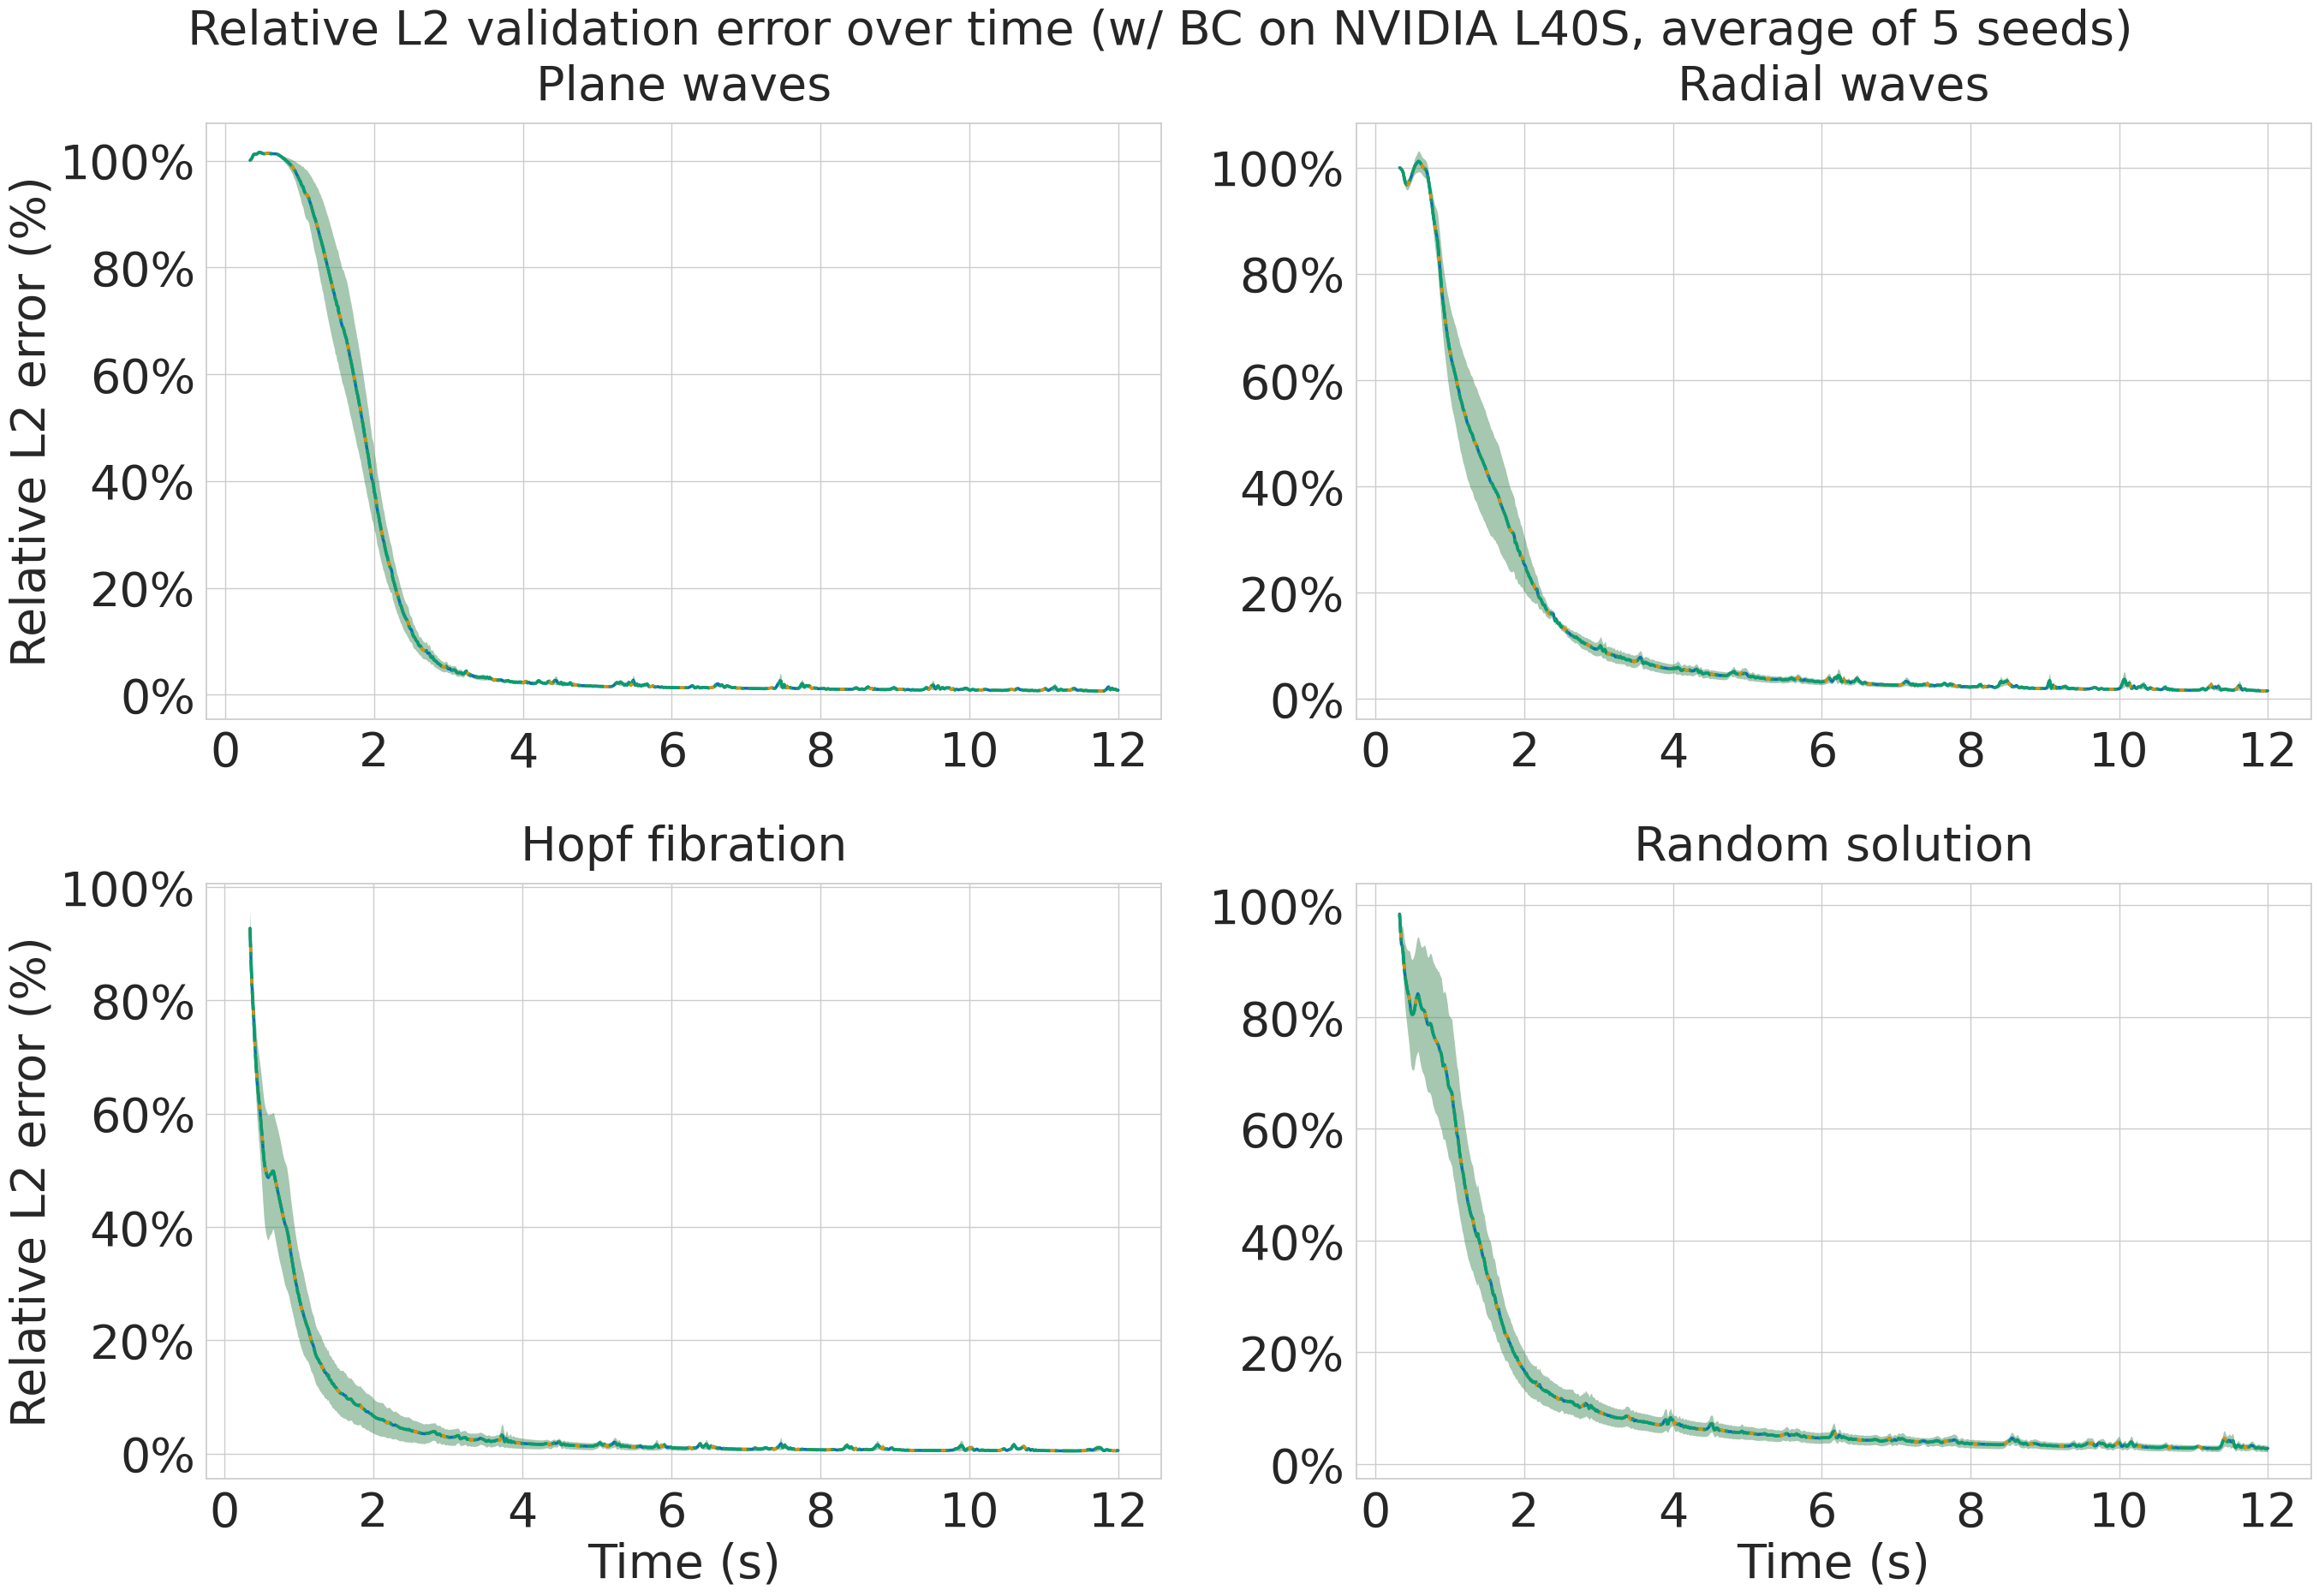

In [148]:
fs = 40
lfs = 30

plt.rcParams.update({
    'font.size': fs,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': lfs,
    'legend.title_fontsize': lfs,
    'figure.titlesize': fs
})

fig = plt.figure(figsize=(28, 20))  # taller
gs = gridspec.GridSpec(2, 2, width_ratios=[0.5]*2)

colors = sns.color_palette("colorblind", 3)
line_styles = ['-', '--', '-.', ':']

max_time = 12

axes = []

for i, (soln_num, title) in enumerate(zip(soln_nums, titles)):
    row, col = divmod(i, 2)
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

    exps_soln_num = exps[soln_num]

    logs = [
        pd.read_csv(os.path.join(exp, 'log.tsv'), sep='\t')
        for exp in exps_soln_num
    ]

    assert len(logs) == 5

    x_values, y_smooth, y_std = interpolate_runs(logs, max_time=max_time)

    for log, color, line_style in zip(logs, colors, line_styles):
        ax.fill_between(x_values, y_smooth - y_std, y_smooth + y_std, alpha=0.2, color=color, linewidth=0)
        ax.plot(x_values, y_smooth, linewidth=2.5, color=color, linestyle=line_style)

    ax.set_title(title, pad=20)

    # x label only on bottom row
    if row == 1:
        ax.set_xlabel("Time (s)")
    else:
        ax.set_xlabel("")

    # y label only on left column
    if col == 0:
        ax.set_ylabel("Relative L2 error (%)")
    else:
        ax.set_ylabel("")

    # y ticks: 0% to 100% in steps of 20
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

    # x ticks: 0, 2, 4, ... up to max x value for this subplot
    x_max = x_values[-1]
    ax.set_xticks(np.arange(0, max_time + 2, 2))

# Shared title using suptitle — centered over all subplots
fig.suptitle('Relative L2 validation error over time (w/ BC on NVIDIA L40S, average of 5 seeds)', fontsize=fs, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig(f"timing_plots.pdf", bbox_inches='tight')
plt.show()